# Implementing a (simplified) Denoising Diffusion Probabilistic Model (DDPM)

The final goal is to implement a simple DDPM, using inspiration from the original paper (add link). We will also introduce some simple modification inspired by the DDIM paper.

We will proceed incrementally, and complete the following tasks : 
- Load an image and add noise to it using inspiration from the DDPM paper by creating a noise generator function that can reproduce the effect of gradually adding noise to an image
- Create a simple denoiser with an "hourglass" shape
- Implement the training logic with the denoiser and the noise generator
- Train this setup on a subset of mnist dataset and qualitatively evaluate the results

Once those first steps are completed we will gradually add some improvments to try and improve our model
- Improve the noise generator schedule by using inspiration from the DDIM paper
- Update the denoiser to add more layers and the skip connections as seen in the original unet
- Replace the simple conv layers by residual blocks
- Add group normalisation layers to the residual blocks
- Add Self-attention mechanism (with positionnal embeddings)

For each step some code skeleton will be provided, follow the comments to fill the missing parts, some helper function are also provided to speed up some parts

## Required imports

In [1]:
import torch
import random
import numpy as np
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from timm.utils import ModelEmaV3
import math

## Helper Functions

The following block contains elements needed to implement the self-attention layers in the Unet variant used in the DDPM paper. Il will be useful later.

In [2]:
class SinusoidalEmbeddings(nn.Module):
    """ Sinusoidal Embeddings encoder 

        For use with self-attention layers

        from https://towardsdatascience.com/diffusion-model-from-scratch-in-pytorch-ddpm-9d9760528946/

    """
    def __init__(self, time_steps:int, embed_dim: int):
        super().__init__()
        position = torch.arange(time_steps).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float() * -(math.log(10000.0) / embed_dim))
        embeddings = torch.zeros(time_steps, embed_dim, requires_grad=False)
        embeddings[:, 0::2] = torch.sin(position * div)
        embeddings[:, 1::2] = torch.cos(position * div)
        self.embeddings = embeddings

    def forward(self, x, t):
        embeds = self.embeddings[t].to(x.device)
        return embeds[:, :, None, None]

class SelfAttention(nn.Module):
    """ Self attention Layer
    
        from https://discuss.pytorch.org/t/attention-in-image-classification/80147/2

        Works with image tensor of any shape
        
    """
    def __init__(self,in_dim,activation):
        super(SelfAttention,self).__init__()
        self.chanel_in = in_dim
        self.activation = activation
        
        self.query_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim//8 , kernel_size= 1)
        self.key_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim//8 , kernel_size= 1)
        self.value_conv = nn.Conv2d(in_channels = in_dim , out_channels = in_dim , kernel_size= 1)
        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax  = nn.Softmax(dim=-1) #
    def forward(self,x):
        """
            inputs :
                x : input feature maps( B X C X W X H)
            returns :
                out : self attention value + input feature 
                attention: B X N X N (N is Width*Height)
        """
        m_batchsize,C,width ,height = x.size()
        proj_query  = self.query_conv(x).view(m_batchsize,-1,width*height).permute(0,2,1) # B X CX(N)
        proj_key =  self.key_conv(x).view(m_batchsize,-1,width*height) # B X C x (*W*H)
        energy =  torch.bmm(proj_query,proj_key) # transpose check
        attention = self.softmax(energy) # BX (N) X (N) 
        proj_value = self.value_conv(x).view(m_batchsize,-1,width*height) # B X C X N

        out = torch.bmm(proj_value,attention.permute(0,2,1) )
        out = out.view(m_batchsize,C,width,height)
        
        out = self.gamma*out + x
        return out,attention

### Check for GPU availability

In [34]:
# From IAO4 tutorial on GANs
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

#Additional Info when using cuda
if device == 'cuda':
    print('Number of GPU(s):', torch.cuda.device_count())
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using cuda device
Number of GPU(s): 1
NVIDIA GeForce GTX 1650 with Max-Q Design
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


### Adding simple gaussian noise to an image 

In order to introduce the noise generation process to see its effects first load an image using the PIL/Pillow library, convert it to a tensor (to be used with pytorch) and add noise to the image with the following schedule. 

The original schedule was : 
$ x_t = (1-\beta) \cdot x_{t-1} + \beta \cdot \epsilon $

For simplification purpose we will start by implementing a more direct noise generation process :
$ x_t = (1-\beta_t) \cdot x_0 + \beta_t \cdot \epsilon $

For this part, we will set $\beta_t$ as a constant between $0$ and $1$ and $\epsilon$ will represent the 2D noise added to the image (see `torch.rand_like` or `torch.randn` documentation to generate the noise)

Note : if you use the provided example or any other `.png` image, be sure to remove the "alpha" channel from your image befor the conversion to grayscale

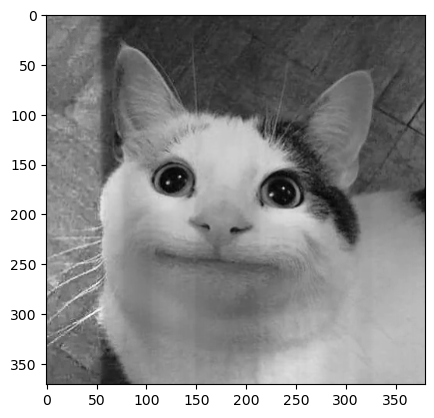

In [6]:
# Load an image using pillow and convert it to greyscale

img_raw = Image.open("test_img.png") # Load an image 
img = torchvision.transforms.functional.pil_to_tensor(img_raw) # Convert to tensor
img = img[0:3,:,:] # Remove the alpha channel for simplification
img = torchvision.transforms.functional.rgb_to_grayscale(img) # Convert to grayscale (again for simplification)
img = img.double() # Convert to doubles 
img = F.normalize(img) # Normalize the image 
plt.imshow(img[0], cmap="Greys_r") # Display the image (ideally in black & white

In [14]:
# [TODO] Now create a function to add some noise according to the schedule 
# This function has to work with 4D tensors
def noise_generator(x, beta):
    # Generate 2D noise
    eps = torch.randn_like(x)
    # Add some dimensions to beta (to be able to work on a batch of multi-channel images 
    #beta = torch.tensor(beta, dtype=x.dtype, device=x.device)
    beta_dim = beta.view(-1, 1, 1, 1)
    # Create the noisy version of the input    
    noisy_x = (1 - beta_dim) * x + beta_dim * eps
    return noisy_x

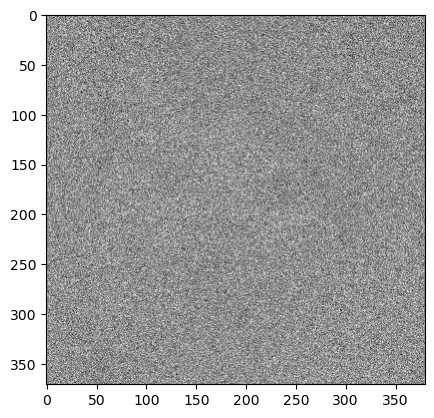

In [28]:
# Test your function on the image you loaded before
noisy_img = noise_generator(img, torch.tensor([.2])) # Choose a value for beta between 0 and 1
plt.imshow(noisy_img[0][0], cmap="Greys_r") 

### Apply the noise function with increasing strength on the Mnist dataset

Text(0.5, 1.0, 'Number 6')

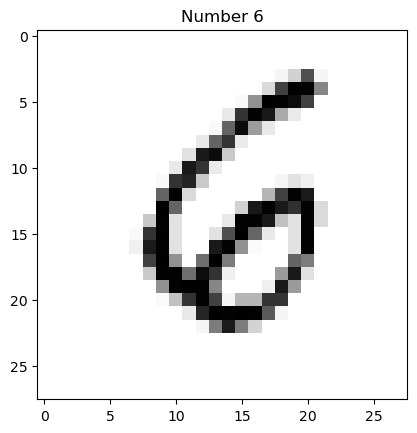

In [26]:
# Load the mnist dataset
dataset = torchvision.datasets.FashionMNIST(
    root="fashionmnist/", train=True, download=True, transform=torchvision.transforms.ToTensor()
)
# select and display a random image (as a sanity check)
idx = np.random.randint(0, len(dataset.train_data))
plt.imshow(dataset.train_data[idx], cmap='Grays') 
plt.title(f'Number {dataset.train_labels[idx]}')

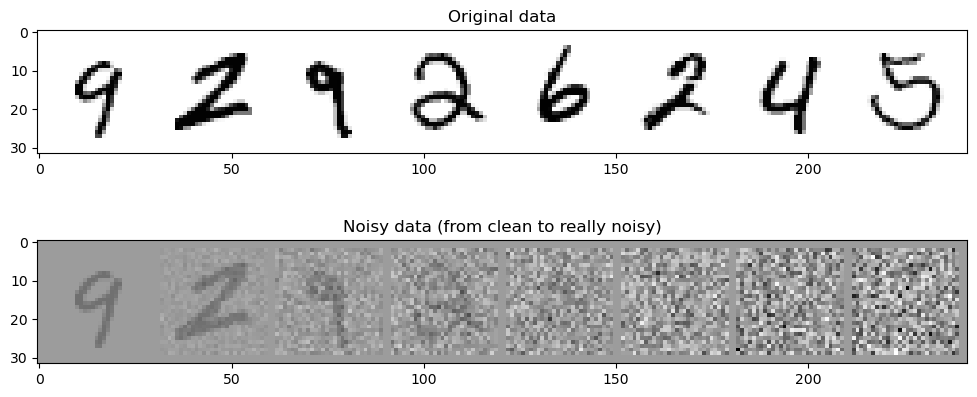

In [30]:

# Iterate on the data loader to generate a batch of images
sample_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)
sample, _= next(iter(sample_dataloader))

# [TODO] create a vector with the same number of item as the samples (e.g. 8), gradually increasing from 0 to 1
vector_beta = torch.linspace(0, 1, steps=sample.size(0), device=sample.device)
# [TODO] Add the noise to each samples using the function we've built earlier
noisy_sample = noise_generator(sample, vector_beta)

# Display the samples and their reference 
ig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Original data")
axs[0].imshow(torchvision.utils.make_grid(sample)[0], cmap="Greys")
# Plotting the noised version
axs[1].set_title("Noisy data (from clean to really noisy)")
axs[1].imshow(torchvision.utils.make_grid(noisy_sample)[0], cmap="Greys")


## Building and training the denoiser to generate images

We will use the next two cells to build differents variants of denoiser to compare their performance.

### Simple Denoiser 

We will start by building in the `HourGlassNet` class a simple CNN with the following architecture :

![alt text](illus/HourGlass.png "HourGlass net")

Next, complete the training loop skeleton below to train your denoiser, using the `noise_generator` function you've built earlier
The last cell will allow you to test your model. Be sure to save the image for comparison later.

### Simple Unet 

Modify your `HourGlassNet` (or create a new class) by adding some skip connections as shown in the diagram below

![alt text](illus/Unet_simple.png "Simplified UNET")

Again modify the training loop if necessary and save the outputs for comparison later.

### Simplified DDPM Unet

Using the helper functions provided at the beginning, add self-attention layers to your model.

![alt text](illus/DDPM_Simple.png "Simplified DDPM")

You will also need to modify the `conv2D` layers of your network and replace them with residual blocks as shown in the diagram below : 

![alt text](illus/ResBlock.png "Residual Block")

Again modify the training loop if necessary and save the outputs for comparison later.

In [31]:
# [TODO]Build your custom blocks here with the class LayerBlock(nn.Module) for the DDPM UNet

# Optionnal, add groupnorm or batchnorm & dropout
class LayerBlock(nn.Module):

    def __init__(self, in_channels, out_channels, k_size, pad_size, act):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=k_size, padding=pad_size)
        self.norm1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=k_size, padding=pad_size)
        self.act = act
            
    def forward(self, x, time_embd, attention=False):
        residual = self.conv1(x)
        residual = self.norm1(residual)
        residual = self.act(residual)
        residual = self.conv2(residual)        
        return self.act(x + residual) # spoilers

In [33]:
# [TODO] Build your networks here starting withe the simple denoising network (called hourglass here)
class HourGlassNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.act = nn.ReLU() # Or any other activation of your choixe
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.maxpool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        
        self.conv5 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.upscale5 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv6 = nn.Conv2d(32, 1, kernel_size=3, padding=1)
        self.upscale6 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # Place your layers definition (with parameters) here. Do not forget the upscaling & downscaling operations
     
        
    def forward(self, x):
        x = self.act(self.maxpool1(self.conv1(x)))
        x = self.act(self.maxpool2(self.conv2(x)))
        x = self.act(self.conv3(x))
        x = self.act(self.conv4(x))
        x = self.act(self.upscale5(self.conv5(x)))
        x = self.act(self.upscale6(self.conv6(x)))
        return x

In [64]:
class HourGlassNet2(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.act = nn.ReLU() # Or any other activation of your choixe
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.maxpool1 = nn.MaxPool2d(2, 2)
        self.batchnorm1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool2d(2, 2)
        self.batchnorm2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.batchnorm3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.batchnorm4 = nn.BatchNorm2d(64)
        
        self.conv5 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.upscale5 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.batchnorm5 = nn.BatchNorm2d(32)
        self.conv6 = nn.Conv2d(32, 1, kernel_size=3, padding=1)
        self.upscale6 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.batchnorm6 = nn.BatchNorm2d(1)
        # Place your layers definition (with parameters) here. Do not forget the upscaling & downscaling operations
     
        
    def forward(self, x):
        residue1 = x
        x = self.act(self.batchnorm1(self.maxpool1(self.conv1(x))))
        residue2 = x
        x = self.act(self.batchnorm2(self.maxpool2(self.conv2(x))))
        residue3 = x
        x = self.act(self.batchnorm3(self.conv3(x)))
        x = self.act(self.batchnorm4(self.conv4(x)))
        x = x + residue3
        x = self.act(self.batchnorm5(self.upscale5(self.conv5(x))))
        x = x + residue2
        x = self.act(self.batchnorm6(self.upscale6(self.conv6(x))))
        x = x + residue1
        return x

In [62]:
# Training Logic
batch_size = 32
# [TODO] Hyperarameters
n_epochs = 10
ema_decay = 0.9999
learning_rate = 1e-3
n_steps = 1000

def train_model(net):  
    # [TODO] Create the network 
    net.to(device)
    net.train()
    
    # [TODO] Set the correct loss function 
    loss_fn = nn.MSELoss()
    
    opt = torch.optim.Adam(net.parameters(), lr=learning_rate) # Change at your own risk ;) 
    train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True) 
    losses = [] # For post training visualisation of the loss variation
    
    # [OPTIONNAL] Add EMA to your training pipeline (for better performance in theory)
    # ema = ModelEmaV3(net, decay=ema_decay)
    
    # [TODO] Create a vector for betas values (linear sampling between 0 & 1)
    vector_beta = torch.linspace(0, 1, steps=n_steps, device=device)
    
    # The training loop
    for epoch in range(n_epochs):
    
        for x, y in tqdm(train_dataloader):
            # Get some data and prepare the corrupted version
            x = x.to(device)
            
            # [TODO] Generate the noisy variants of x using the noise generator function
            idx = torch.randint(0, len(vector_beta), (batch_size,), device=device)
            sampled_beta = vector_beta[idx]
            noisy_x = noise_generator(x, sampled_beta)
            
            # [TODO] Process the input with the denoiser
            output = net(noisy_x)
            
            # [TODO] Compute the loss
            loss = loss_fn(output, x)
            
            # Run the optimizer 
            opt.zero_grad()
            loss.backward()
            opt.step()
    
            # Uncomment if you wish to use EMA
            # ema.update(net)
            
            # Store the loss in the log for visualisation
            losses.append(loss.item())       
            
    
        # Display the current loss for this step
        avg_loss = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Finished epoch {epoch+1}. Average loss for this epoch: {avg_loss:05f}")
        # [OPTIONNAL]
    return net, losses

In [ ]:
net = HourGlassNet(in_channels=1, out_channels=1)    
net, losses = train_model(net=net)

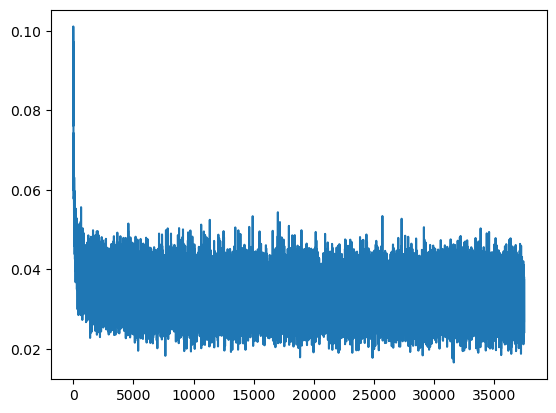

In [60]:
# Display the training loss
plt.plot(losses)

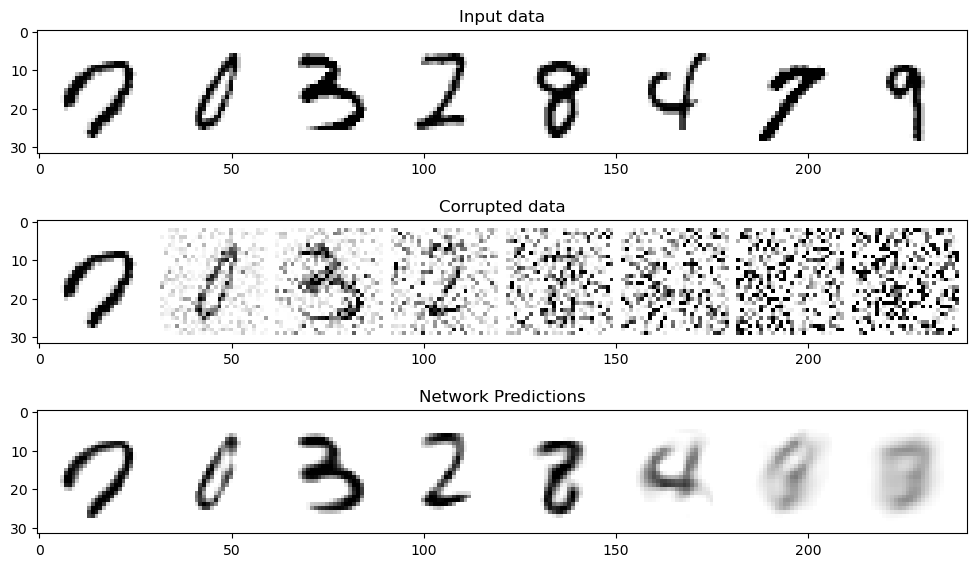

In [47]:
def test_model(net):
    # Load a batch of images to see the effect of your trained model
    test_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True) 
    
    
    x, y = next(iter(test_dataloader))
    x = x[:8]  # 
    
    # Add some corruption to the sample to see the effect
    beta_schedule = torch.linspace(0, 1, n_steps)
    
    t = [0, 200, 300, 400, 500, 600, 800, 999]
    betas = beta_schedule[t]
    noised_x = noise_generator(x, betas)
    
    # Get the model predictions
    with torch.no_grad():
        preds = net(noised_x.to(device)).detach().cpu()
    
    # Plot
    fig, axs = plt.subplots(3, 1, figsize=(12, 7))
    axs[0].set_title("Input data")
    axs[0].imshow(torchvision.utils.make_grid(x)[0].clip(0, 1), cmap="Greys")
    axs[1].set_title("Corrupted data")
    axs[1].imshow(torchvision.utils.make_grid(noised_x)[0].clip(0, 1), cmap="Greys")
    axs[2].set_title("Network Predictions")
    axs[2].imshow(torchvision.utils.make_grid(preds)[0].clip(0, 1), cmap="Greys")
    
test_model(net)

In [63]:
net2 = HourGlassNet2(in_channels=1, out_channels=1)
net2, losses2 = train_model(net=net2)

100%|██████████| 1875/1875 [00:13<00:00, 138.35it/s]


Finished epoch 1. Average loss for this epoch: 0.370353


100%|██████████| 1875/1875 [00:13<00:00, 142.72it/s]


Finished epoch 2. Average loss for this epoch: 0.370940


100%|██████████| 1875/1875 [00:13<00:00, 142.25it/s]


Finished epoch 3. Average loss for this epoch: 0.369032


 26%|██▋       | 496/1875 [00:03<00:09, 141.91it/s]


KeyboardInterrupt: 

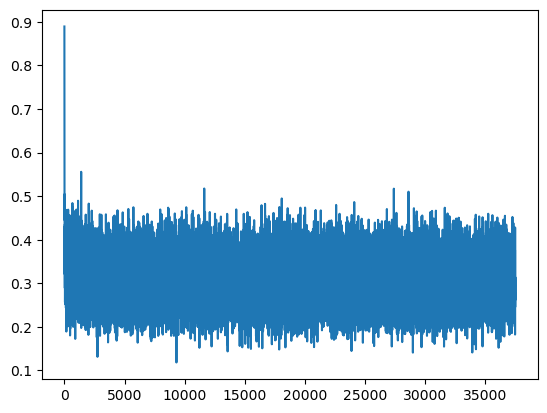

In [58]:
# Display the training loss
plt.plot(losses2)  # Change the upper bound if needed to see the loss variations more clearly 

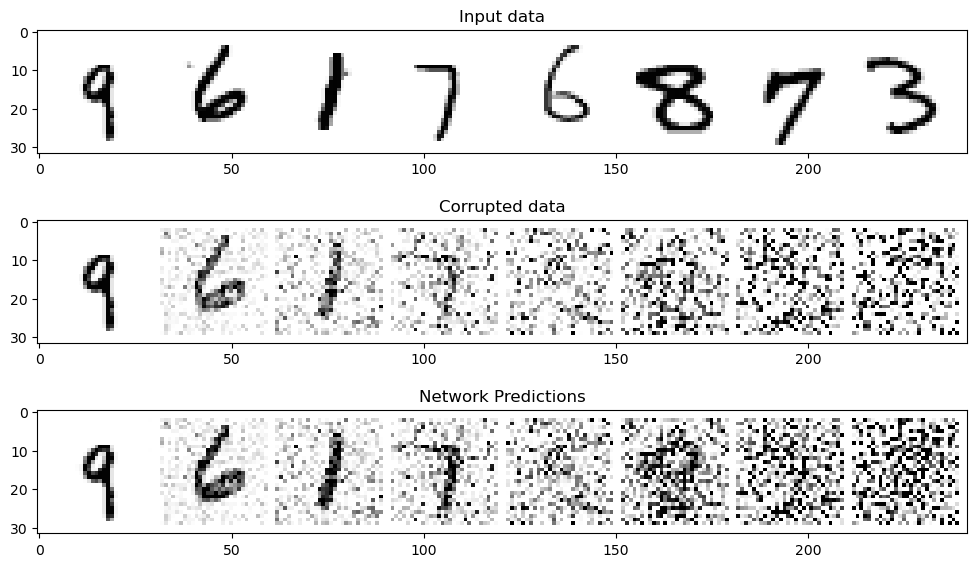

In [59]:
test_model(net2)